# GLOF Multi-Sensor Glacial Lake EDA

**Exploratory Data Analysis** of the merged monthly multi-sensor time series across 494 glacial lakes in Nepal (2015–2025).

**Dataset**: master_multisensor_merged.csv  
**Rows**: 65,208 (494 lakes × 132 months)  
**Columns**: 22 (GL_ID, date, year, month + 5 sensor suites)  
**Purpose**: Characterize data quality, seasonal patterns, and anomalies in preparation for autoencoder-based anomaly detection and hazard assessment.

## 0. Setup

**Why this matters**: A robust EDA foundation ensures correct data loading, proper date parsing, consistent visualization styling, and reproducible results. We standardize fonts and plotting options here to maintain publication-quality figures throughout.

In [5]:
# File path (change as needed)
DATA_PATH = '../data/processed/master_multisensor_merged.csv'

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set font and style globally (before any plotting)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Seaborn theme with consistent styling
sns.set_theme(style="whitegrid")
color_palette = sns.color_palette("husl", 8)

# Create output directory for figures
output_dir = Path('../outputs/figures')
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {output_dir}")

Output directory: ..\outputs\figures


In [6]:
# Load data
df = pd.read_csv(DATA_PATH)

# Parse date as datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by GL_ID and date for temporal consistency
df = df.sort_values(['GL_ID', 'date']).reset_index(drop=True)

print("\n" + "="*70)
print("DATASET LOADED")
print("="*70)
print(f"\nShape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique lakes (GL_ID): {df['GL_ID'].nunique()}")
print(f"Months per lake: {df.groupby('GL_ID').size().mode().values[0]}")


DATASET LOADED

Shape: (65208, 22)
Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00
Unique lakes (GL_ID): 494
Months per lake: 132


In [7]:
# Display data types and basic info
print("\nData Types:")
print(df.dtypes)

print("\n" + "="*70)
print("BASIC STATISTICS")
print("="*70)
print(df.describe())


Data Types:
GL_ID                           object
date                    datetime64[ns]
year                             int64
month                            int64
ERA5_temp_K                    float64
ERA5_temp_C                    float64
GPM_Precipitation_mm           float64
GPM_Scan_Count                   int64
LST_Day_C                      float64
LST_Night_C                    float64
LST_Scan_Count                   int64
S1_observations                  int64
VV_mean                        float64
VV_median                      float64
VV_stdDev                      float64
VH_mean                        float64
VH_median                      float64
VH_stdDev                      float64
angle_mean                     float64
S2_observations                  int64
S2_NDWI_mean                   float64
S2_water_area_km2              float64
dtype: object

BASIC STATISTICS
                                date          year         month  \
count                        

In [8]:
# Missing value counts
print("\n" + "="*70)
print("MISSING VALUES")
print("="*70)
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Count': missing_counts.values,
    'Percentage': missing_pct.values
})
print(missing_df.to_string(index=False))


MISSING VALUES
              Column  Count  Percentage
        S2_NDWI_mean  30803       47.24
           VH_median   8228       12.62
           VV_median   8228       12.62
           VV_stdDev   8228       12.62
             VV_mean   8228       12.62
             VH_mean   8228       12.62
           VH_stdDev   8228       12.62
          angle_mean   8199       12.57
         ERA5_temp_C      0        0.00
         ERA5_temp_K      0        0.00
                date      0        0.00
               GL_ID      0        0.00
               month      0        0.00
                year      0        0.00
      LST_Scan_Count      0        0.00
     S1_observations      0        0.00
           LST_Day_C      0        0.00
         LST_Night_C      0        0.00
      GPM_Scan_Count      0        0.00
GPM_Precipitation_mm      0        0.00
     S2_observations      0        0.00
   S2_water_area_km2      0        0.00


---

## 1. Missingness Analysis

**Why this matters**: Missingness patterns reveal sensor limitations (cloud cover, SAR revisit gaps), seasonal acquisition windows, and data quality issues. Understanding these patterns is essential for deciding imputation strategies before feeding data into the autoencoder for anomaly detection.

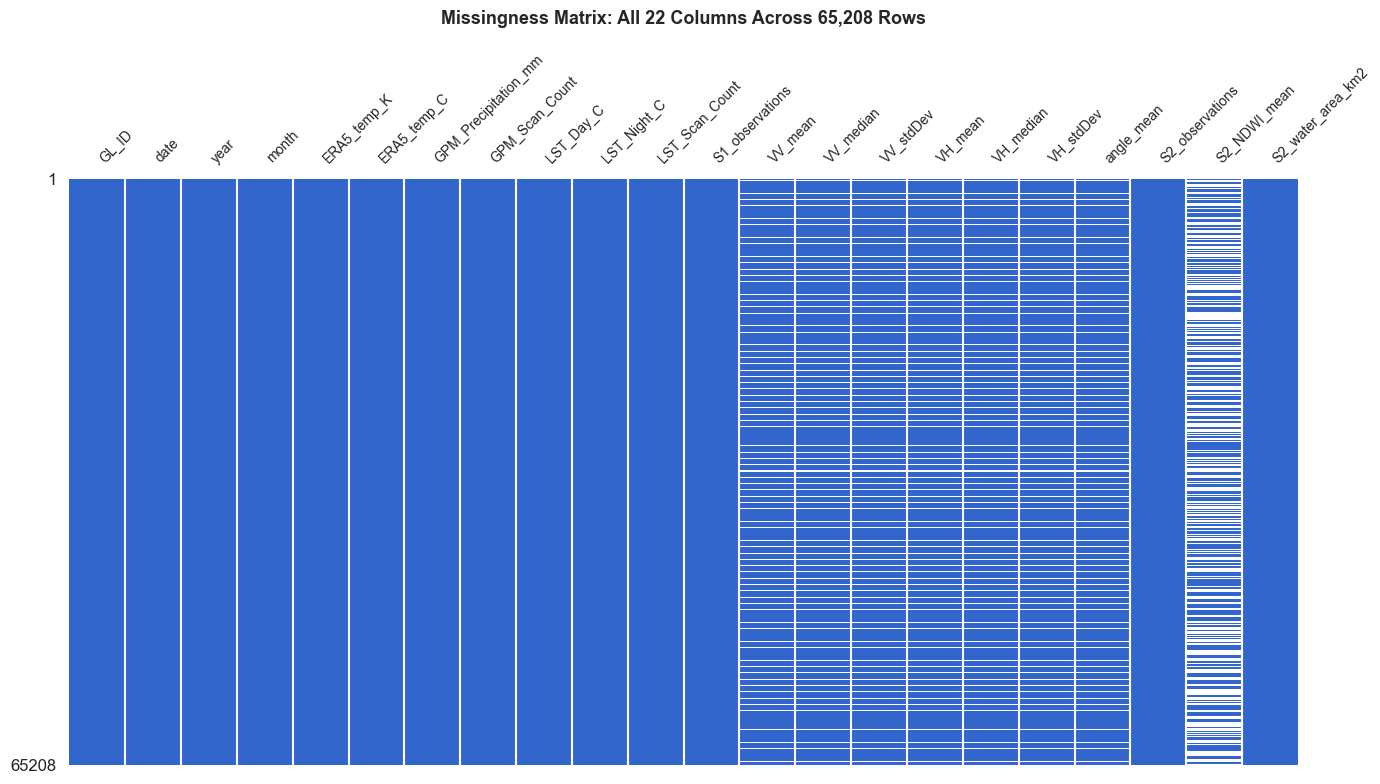

Saved: 01_missingness_matrix.png


In [9]:
# Missingness matrix visualization
fig, ax = plt.subplots(figsize=(14, 8))
msno.matrix(df, ax=ax, sparkline=False, fontsize=10, color=(0.2, 0.4, 0.8))
plt.title('Missingness Matrix: All 22 Columns Across 65,208 Rows', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(output_dir / '01_missingness_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 01_missingness_matrix.png")

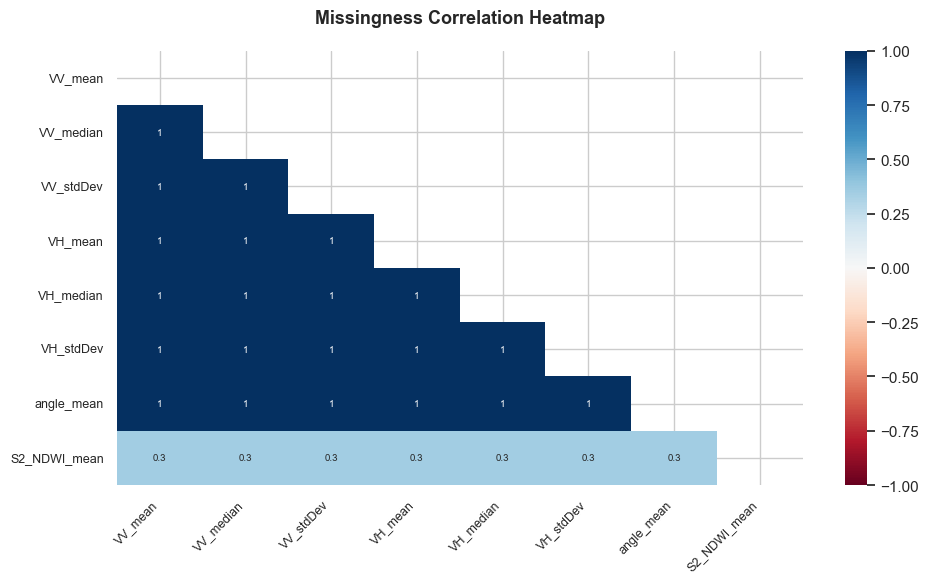

Saved: 02_missingness_heatmap.png


In [10]:
# Missingness heatmap (correlation of missingness)
fig, ax = plt.subplots(figsize=(10, 6))
msno.heatmap(df, ax=ax, fontsize=9)
plt.title('Missingness Correlation Heatmap', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(output_dir / '02_missingness_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 02_missingness_heatmap.png")

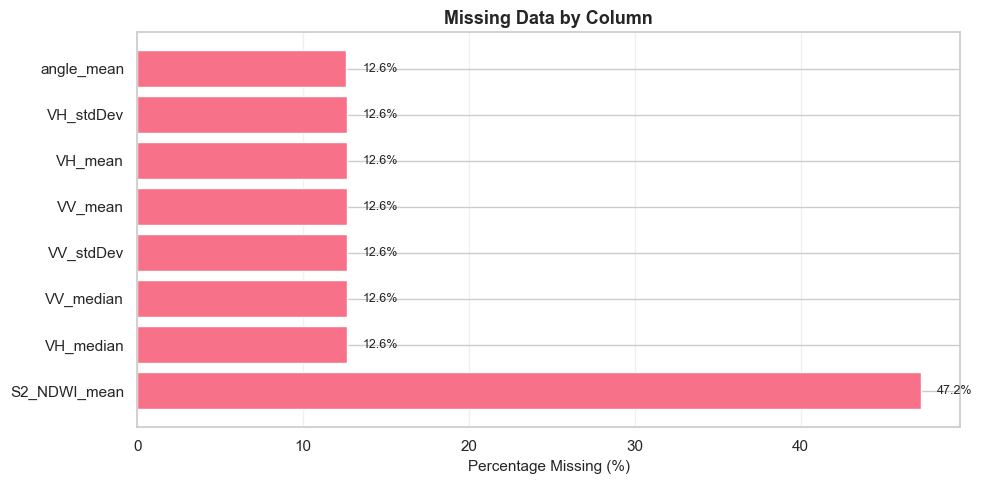

Saved: 03_missing_percent_by_column.png


In [11]:
# Bar chart: % missing per column
missing_pct_sorted = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct_sorted = missing_pct_sorted[missing_pct_sorted > 0]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(missing_pct_sorted)), missing_pct_sorted.values, color=color_palette[0])
ax.set_yticks(range(len(missing_pct_sorted)))
ax.set_yticklabels(missing_pct_sorted.index)
ax.set_xlabel('Percentage Missing (%)', fontsize=11)
ax.set_title('Missing Data by Column', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, val) in enumerate(missing_pct_sorted.items()):
    ax.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / '03_missing_percent_by_column.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 03_missing_percent_by_column.png")

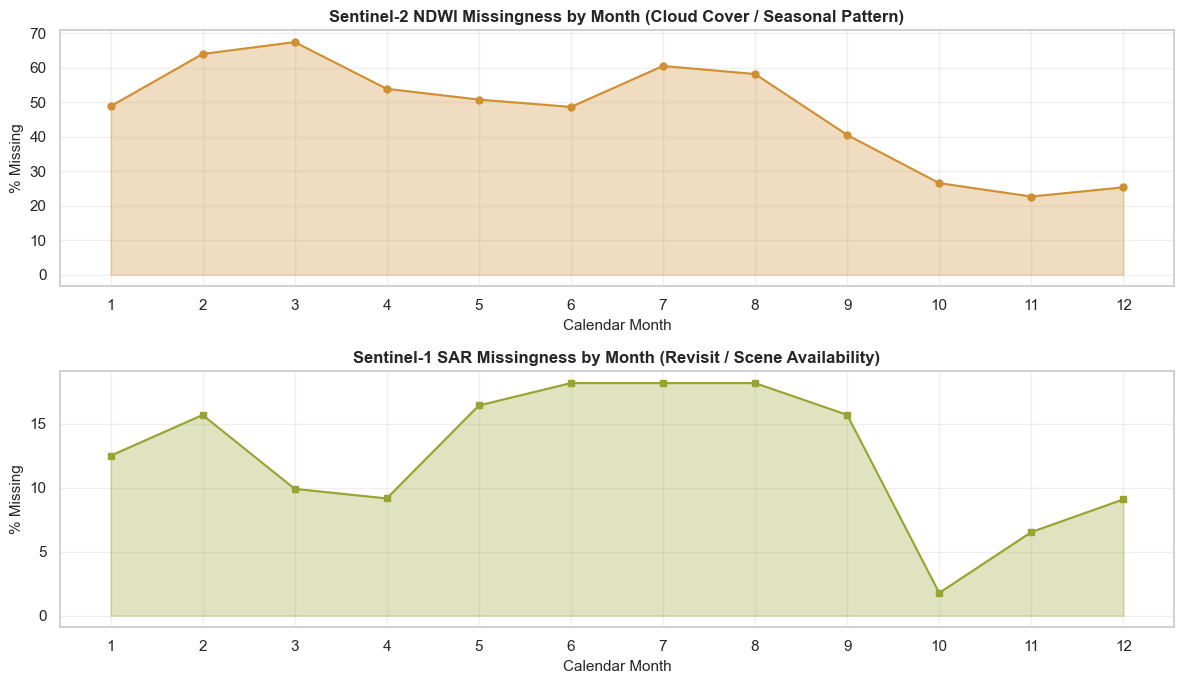

Saved: 04_seasonal_missingness.png

Peak S2 missingness month: 3 (67.4%)
Peak SAR missingness month: 6 (18.2%)


In [12]:
# Seasonal missingness pattern: group by month, compute % missing for S2_NDWI_mean and SAR columns
sar_cols = ['VV_mean', 'VV_median', 'VV_stdDev', 'VH_mean', 'VH_median', 'VH_stdDev', 'angle_mean']

seasonal_missing = df.groupby('month')[['S2_NDWI_mean'] + sar_cols].apply(
    lambda x: (x.isnull().sum() / len(x) * 100)
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

# S2_NDWI_mean seasonal pattern
ax1.plot(seasonal_missing.index, seasonal_missing['S2_NDWI_mean'], 
         marker='o', markersize=5, linewidth=1.5, color=color_palette[1], label='S2_NDWI_mean')
ax1.fill_between(seasonal_missing.index, seasonal_missing['S2_NDWI_mean'], alpha=0.3, color=color_palette[1])
ax1.set_xlabel('Calendar Month', fontsize=11)
ax1.set_ylabel('% Missing', fontsize=11)
ax1.set_title('Sentinel-2 NDWI Missingness by Month (Cloud Cover / Seasonal Pattern)', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xticks(range(1, 13))

# SAR columns seasonal pattern (averaged)
sar_avg = seasonal_missing[sar_cols].mean(axis=1)
ax2.plot(seasonal_missing.index, sar_avg, 
         marker='s', markersize=5, linewidth=1.5, color=color_palette[2], label='SAR (avg)')
ax2.fill_between(seasonal_missing.index, sar_avg, alpha=0.3, color=color_palette[2])
ax2.set_xlabel('Calendar Month', fontsize=11)
ax2.set_ylabel('% Missing', fontsize=11)
ax2.set_title('Sentinel-1 SAR Missingness by Month (Revisit / Scene Availability)', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig(output_dir / '04_seasonal_missingness.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 04_seasonal_missingness.png")
print(f"\nPeak S2 missingness month: {seasonal_missing['S2_NDWI_mean'].idxmax()} ({seasonal_missing['S2_NDWI_mean'].max():.1f}%)")
print(f"Peak SAR missingness month: {sar_avg.idxmax()} ({sar_avg.max():.1f}%)")

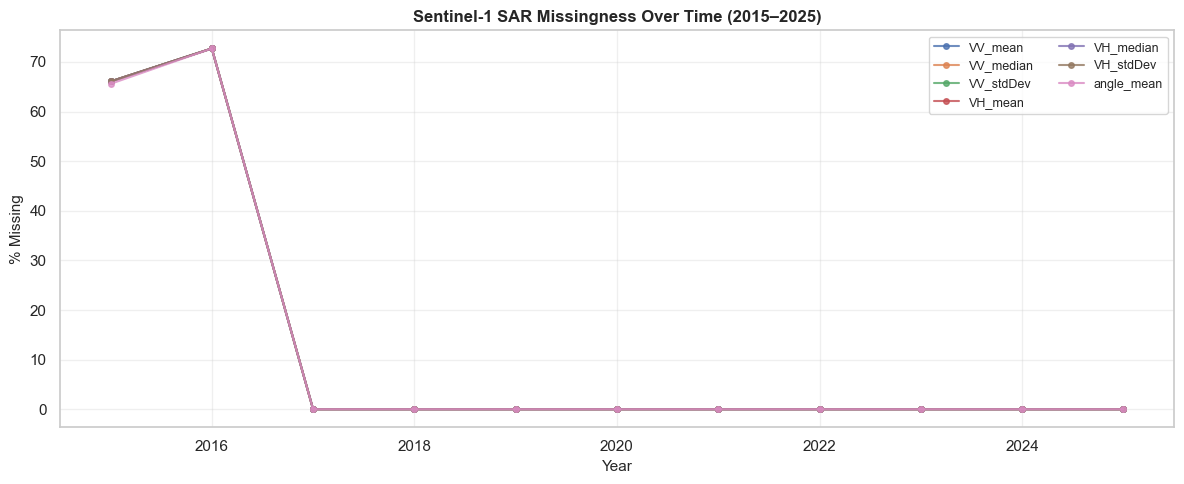

Saved: 05_annual_sar_missingness.png


In [13]:
# Temporal missingness pattern: group by year, compute % missing for SAR columns
annual_missing_sar = df.groupby('year')[sar_cols].apply(
    lambda x: (x.isnull().sum() / len(x) * 100)
)

fig, ax = plt.subplots(figsize=(12, 5))
for col in sar_cols:
    ax.plot(annual_missing_sar.index, annual_missing_sar[col], 
            marker='o', markersize=4, linewidth=1.5, label=col, alpha=0.8)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('% Missing', fontsize=11)
ax.set_title('Sentinel-1 SAR Missingness Over Time (2015–2025)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='best', ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / '05_annual_sar_missingness.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 05_annual_sar_missingness.png")

In [14]:
# Validate: S2_observations == 0 should imply S2_NDWI_mean is null
print("\n" + "="*70)
print("VALIDATION: S2_observations vs S2_NDWI_mean")
print("="*70)

# Case 1: S2_observations == 0, S2_NDWI_mean is null
case1 = ((df['S2_observations'] == 0) & (df['S2_NDWI_mean'].isnull())).sum()
total_case1_possible = (df['S2_observations'] == 0).sum()

# Case 2: S2_observations > 0, S2_NDWI_mean is not null
case2 = ((df['S2_observations'] > 0) & (df['S2_NDWI_mean'].notnull())).sum()
total_case2_possible = (df['S2_observations'] > 0).sum()

# Inconsistencies
inconsistent_zero = ((df['S2_observations'] == 0) & (df['S2_NDWI_mean'].notnull())).sum()
inconsistent_nonzero = ((df['S2_observations'] > 0) & (df['S2_NDWI_mean'].isnull())).sum()

print(f"\nS2_observations == 0: {total_case1_possible} rows")
print(f"  → S2_NDWI_mean is null: {case1} ({case1/total_case1_possible*100:.1f}%)")
print(f"  → S2_NDWI_mean is NOT null (inconsistent): {inconsistent_zero}")

print(f"\nS2_observations > 0: {total_case2_possible} rows")
print(f"  → S2_NDWI_mean is NOT null: {case2} ({case2/total_case2_possible*100:.1f}%)")
print(f"  → S2_NDWI_mean is null (inconsistent): {inconsistent_nonzero}")

match_rate = (case1 + case2) / len(df) * 100
print(f"\nOverall consistency: {match_rate:.1f}%")


VALIDATION: S2_observations vs S2_NDWI_mean

S2_observations == 0: 11586 rows
  → S2_NDWI_mean is null: 11586 (100.0%)
  → S2_NDWI_mean is NOT null (inconsistent): 0

S2_observations > 0: 53622 rows
  → S2_NDWI_mean is NOT null: 34405 (64.2%)
  → S2_NDWI_mean is null (inconsistent): 19217

Overall consistency: 70.5%


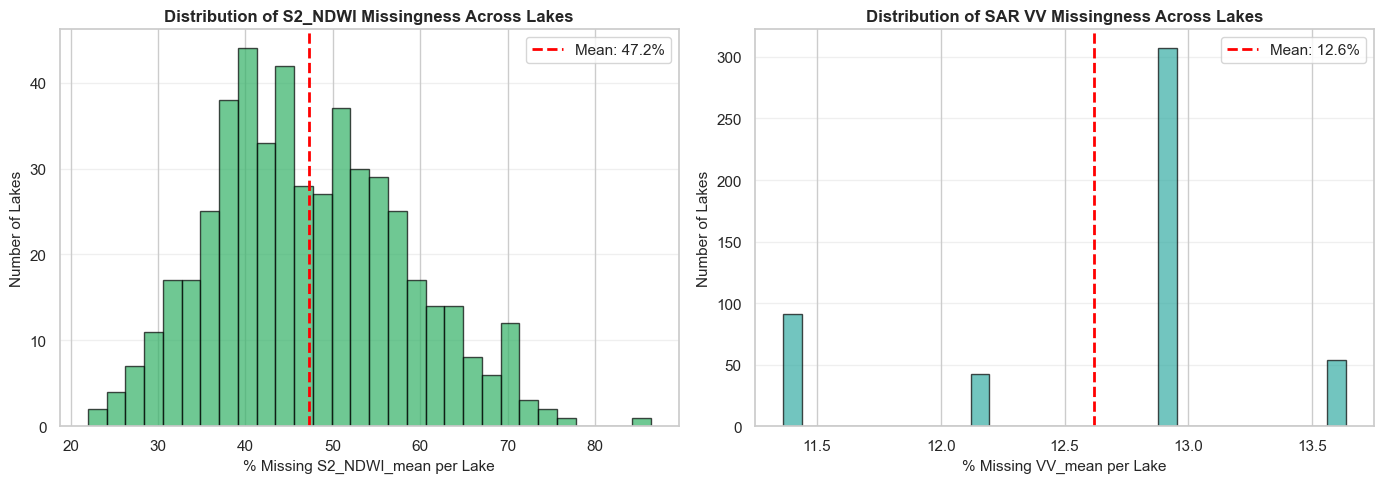

Saved: 06_per_lake_missingness_dist.png


In [15]:
# Per-lake missingness analysis
per_lake_missing = df.groupby('GL_ID').agg({
    'S2_NDWI_mean': lambda x: (x.isnull().sum() / len(x) * 100),
    'VV_mean': lambda x: (x.isnull().sum() / len(x) * 100)
})
per_lake_missing.columns = ['S2_NDWI_pct_missing', 'VV_mean_pct_missing']
per_lake_missing = per_lake_missing.sort_values('S2_NDWI_pct_missing', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of S2_NDWI missingness per lake
axes[0].hist(per_lake_missing['S2_NDWI_pct_missing'], bins=30, color=color_palette[3], edgecolor='black', alpha=0.7)
axes[0].axvline(per_lake_missing['S2_NDWI_pct_missing'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {per_lake_missing['S2_NDWI_pct_missing'].mean():.1f}%")
axes[0].set_xlabel('% Missing S2_NDWI_mean per Lake', fontsize=11)
axes[0].set_ylabel('Number of Lakes', fontsize=11)
axes[0].set_title('Distribution of S2_NDWI Missingness Across Lakes', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Histogram of VV_mean missingness per lake
axes[1].hist(per_lake_missing['VV_mean_pct_missing'], bins=30, color=color_palette[4], edgecolor='black', alpha=0.7)
axes[1].axvline(per_lake_missing['VV_mean_pct_missing'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {per_lake_missing['VV_mean_pct_missing'].mean():.1f}%")
axes[1].set_xlabel('% Missing VV_mean per Lake', fontsize=11)
axes[1].set_ylabel('Number of Lakes', fontsize=11)
axes[1].set_title('Distribution of SAR VV Missingness Across Lakes', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '06_per_lake_missingness_dist.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 06_per_lake_missingness_dist.png")

In [16]:
# Top 10 lakes with highest missingness
print("\nTop 10 Lakes with Highest S2_NDWI_mean Missingness:")
print(per_lake_missing.head(10).to_string())

print("\n\nTop 10 Lakes with Highest VV_mean Missingness:")
per_lake_missing_vv = per_lake_missing.sort_values('VV_mean_pct_missing', ascending=False)
print(per_lake_missing_vv.head(10).to_string())


Top 10 Lakes with Highest S2_NDWI_mean Missingness:
                 S2_NDWI_pct_missing  VV_mean_pct_missing
GL_ID                                                    
GL086581E28078N            86.363636            13.636364
GL086843E27793N            75.757576            12.878788
GL086913E27826N            74.242424            12.878788
GL086918E27823N            73.484848            12.878788
GL086677E27918N            72.727273            12.878788
GL086959E27926N            72.727273            12.878788
GL086793E27679N            71.969697            13.636364
GL086859E27963N            71.212121            12.878788
GL083867E28672N            71.212121            11.363636
GL086576E27900N            71.212121            12.878788


Top 10 Lakes with Highest VV_mean Missingness:
                 S2_NDWI_pct_missing  VV_mean_pct_missing
GL_ID                                                    
GL086847E27611N            53.787879            13.636364
GL086581E28078N            8

---

## 2. Univariate Distributions & Outlier Screening

**Why this matters**: Identifying implausible values (e.g., NDWI outside [−1, 1], negative precipitation) is critical for data quality assurance. Outliers and extreme values need to be flagged before autoencoder training to prevent distortion of the learned latent representation.

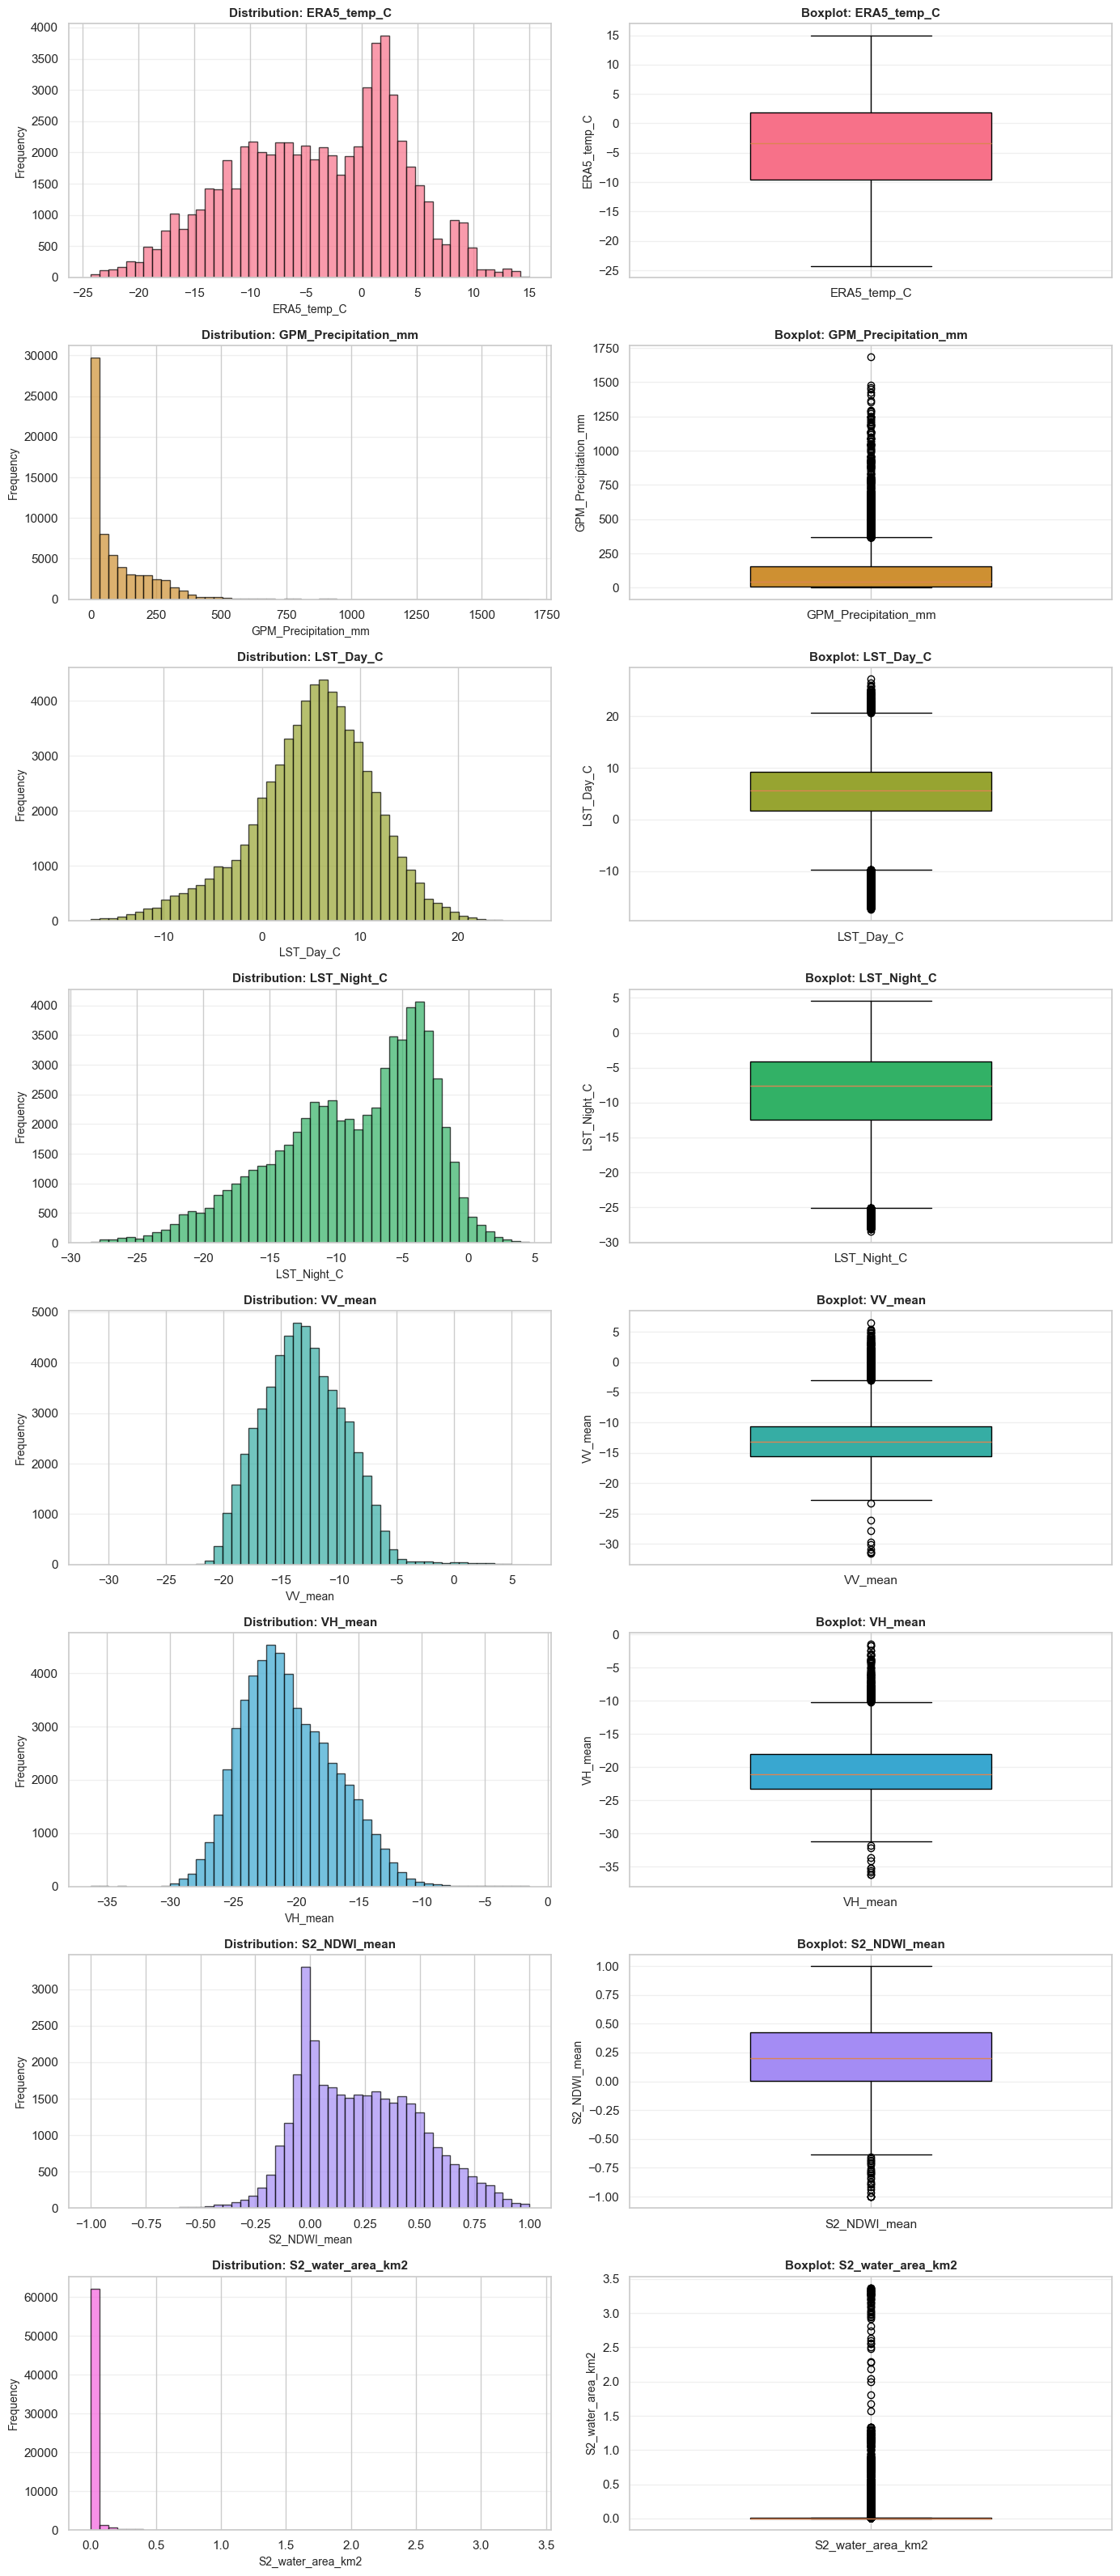

Saved: 07_univariate_distributions.png


In [17]:
# Define continuous variables for univariate analysis
continuous_vars = [
    'ERA5_temp_C', 'GPM_Precipitation_mm', 'LST_Day_C', 'LST_Night_C',
    'VV_mean', 'VH_mean', 'S2_NDWI_mean', 'S2_water_area_km2'
]

# Create histograms and boxplots for each variable
fig, axes = plt.subplots(len(continuous_vars), 2, figsize=(14, 4*len(continuous_vars)))

for idx, var in enumerate(continuous_vars):
    # Histogram
    axes[idx, 0].hist(df[var].dropna(), bins=50, color=color_palette[idx % len(color_palette)], edgecolor='black', alpha=0.7)
    axes[idx, 0].set_xlabel(var, fontsize=10)
    axes[idx, 0].set_ylabel('Frequency', fontsize=10)
    axes[idx, 0].set_title(f'Distribution: {var}', fontsize=11, fontweight='bold')
    axes[idx, 0].grid(axis='y', alpha=0.3)
    
    # Boxplot
    bp = axes[idx, 1].boxplot([df[var].dropna()], vert=True, patch_artist=True,
                              widths=0.5, labels=[var])
    bp['boxes'][0].set_facecolor(color_palette[idx % len(color_palette)])
    axes[idx, 1].set_ylabel(var, fontsize=10)
    axes[idx, 1].set_title(f'Boxplot: {var}', fontsize=11, fontweight='bold')
    axes[idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '07_univariate_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 07_univariate_distributions.png")

In [18]:
# Flag physically implausible values
print("\n" + "="*70)
print("OUTLIER & IMPLAUSIBLE VALUE SCREENING")
print("="*70)

issues = []

# S2_NDWI_mean: should be in [-1, 1]
invalid_ndwi = df[(df['S2_NDWI_mean'].notnull()) & 
                   ((df['S2_NDWI_mean'] < -1) | (df['S2_NDWI_mean'] > 1))]
if len(invalid_ndwi) > 0:
    issues.append(f"S2_NDWI_mean outside [-1, 1]: {len(invalid_ndwi)} rows")
    print(f"\n⚠ S2_NDWI_mean outside [-1, 1]: {len(invalid_ndwi)} rows")
    print(invalid_ndwi[['GL_ID', 'date', 'S2_NDWI_mean']].head(10))

# S2_water_area_km2: should be >= 0
invalid_area = df[df['S2_water_area_km2'] < 0]
if len(invalid_area) > 0:
    issues.append(f"S2_water_area_km2 < 0: {len(invalid_area)} rows")
    print(f"\n⚠ S2_water_area_km2 < 0: {len(invalid_area)} rows")
    print(invalid_area[['GL_ID', 'date', 'S2_water_area_km2']].head(10))

# VV_mean / VH_mean: typical SAR range is [-30, 5] dB
invalid_vv = df[(df['VV_mean'].notnull()) & 
                 ((df['VV_mean'] < -30) | (df['VV_mean'] > 5))]
if len(invalid_vv) > 0:
    issues.append(f"VV_mean outside [-30, 5] dB: {len(invalid_vv)} rows")
    print(f"\n⚠ VV_mean outside [-30, 5] dB: {len(invalid_vv)} rows")
    print(invalid_vv[['GL_ID', 'date', 'VV_mean']].head(10))

invalid_vh = df[(df['VH_mean'].notnull()) & 
                 ((df['VH_mean'] < -30) | (df['VH_mean'] > 5))]
if len(invalid_vh) > 0:
    issues.append(f"VH_mean outside [-30, 5] dB: {len(invalid_vh)} rows")
    print(f"\n⚠ VH_mean outside [-30, 5] dB: {len(invalid_vh)} rows")
    print(invalid_vh[['GL_ID', 'date', 'VH_mean']].head(10))

# GPM_Precipitation_mm: should be >= 0
invalid_precip = df[df['GPM_Precipitation_mm'] < 0]
if len(invalid_precip) > 0:
    issues.append(f"GPM_Precipitation_mm < 0: {len(invalid_precip)} rows")
    print(f"\n⚠ GPM_Precipitation_mm < 0: {len(invalid_precip)} rows")
    print(invalid_precip[['GL_ID', 'date', 'GPM_Precipitation_mm']].head(10))

if len(issues) == 0:
    print("\n✓ No physically implausible values detected.")
else:
    print(f"\nTotal issues found: {len(issues)}")


OUTLIER & IMPLAUSIBLE VALUE SCREENING

⚠ VV_mean outside [-30, 5] dB: 9 rows
                 GL_ID       date    VV_mean
796    GL083549E28854N 2015-05-01   6.526825
5810   GL083713E29090N 2015-03-01   5.283379
45945  GL086767E27963N 2015-10-01 -31.231339
46077  GL086768E27953N 2015-10-01 -31.500630
46209  GL086774E27962N 2015-10-01 -30.870198
46341  GL086777E27951N 2015-10-01 -31.381728
46473  GL086781E27885N 2015-10-01 -30.042504
49236  GL086820E27737N 2015-01-01   5.071662
49238  GL086820E27737N 2015-03-01   5.406961

⚠ VH_mean outside [-30, 5] dB: 24 rows
                 GL_ID       date    VH_mean
3211   GL083638E29104N 2018-08-01 -30.431212
3283   GL083638E29104N 2024-08-01 -30.557559
3295   GL083638E29104N 2025-08-01 -30.143148
5527   GL083706E29180N 2024-08-01 -30.429751
12410  GL083959E28802N 2015-03-01 -36.247528
12412  GL083959E28802N 2015-05-01 -35.172041
12429  GL083959E28802N 2016-10-01 -34.140012
12430  GL083959E28802N 2016-11-01 -32.120913
15627  GL084254E28453N 2019

In [19]:
# Skewness and kurtosis summary
skew_kurt = pd.DataFrame({
    'Variable': continuous_vars,
    'Skewness': [df[var].skew() for var in continuous_vars],
    'Kurtosis': [df[var].kurtosis() for var in continuous_vars],
    'Mean': [df[var].mean() for var in continuous_vars],
    'Std': [df[var].std() for var in continuous_vars]
})

print("\n" + "="*70)
print("SKEWNESS & KURTOSIS SUMMARY")
print("="*70)
print(skew_kurt.round(3).to_string(index=False))


SKEWNESS & KURTOSIS SUMMARY
            Variable  Skewness  Kurtosis    Mean     Std
         ERA5_temp_C    -0.228    -0.667  -3.909   7.398
GPM_Precipitation_mm     2.171     8.910  97.578 121.617
           LST_Day_C    -0.414     0.400   5.211   6.138
         LST_Night_C    -0.630    -0.239  -8.698   5.699
             VV_mean     0.333     0.366 -13.035   3.582
             VH_mean     0.417    -0.060 -20.575   3.704
        S2_NDWI_mean     0.305    -0.364   0.228   0.270
   S2_water_area_km2    17.708   416.801   0.019   0.117


---

## 3. Temporal Structure

**Why this matters**: Temporal patterns reveal seasonal cycles in temperature, precipitation, and lake water extent. Identifying these cycles is crucial for understanding baseline lake behavior versus anomalous outburst signals in a hazard assessment context.

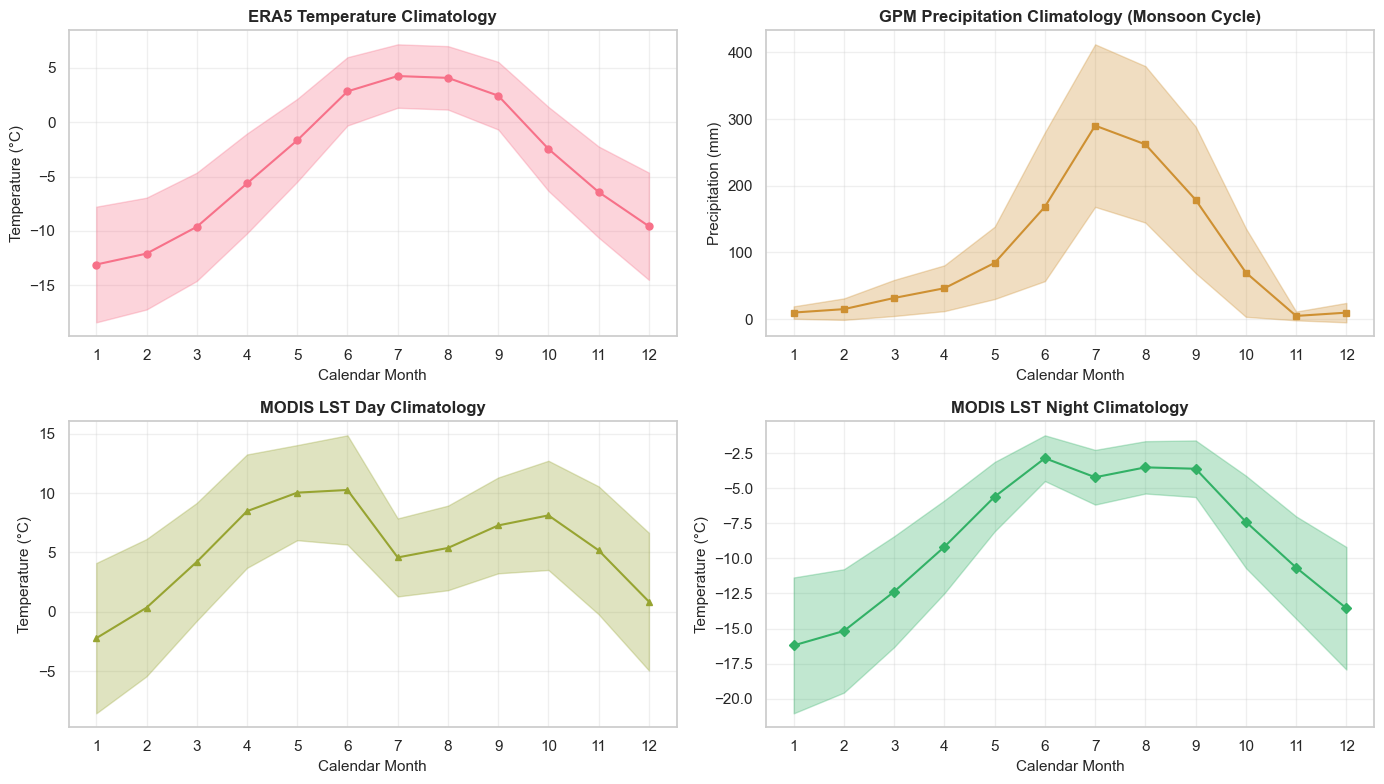

Saved: 08_monthly_climatology.png


In [20]:
# Monthly climatology: mean +/- std for key variables across all lakes
monthly_clim = df.groupby('month').agg({
    'ERA5_temp_C': ['mean', 'std'],
    'GPM_Precipitation_mm': ['mean', 'std'],
    'LST_Day_C': ['mean', 'std'],
    'LST_Night_C': ['mean', 'std']
}).round(2)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ERA5 Temperature
month_idx = monthly_clim.index
temp_mean = df.groupby('month')['ERA5_temp_C'].mean().values
temp_std = df.groupby('month')['ERA5_temp_C'].std().values
axes[0, 0].plot(month_idx, temp_mean, marker='o', markersize=5, linewidth=1.5, color=color_palette[0])
axes[0, 0].fill_between(month_idx, temp_mean - temp_std, temp_mean + temp_std, alpha=0.3, color=color_palette[0])
axes[0, 0].set_xlabel('Calendar Month', fontsize=11)
axes[0, 0].set_ylabel('Temperature (°C)', fontsize=11)
axes[0, 0].set_title('ERA5 Temperature Climatology', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xticks(range(1, 13))

# GPM Precipitation
precip_mean = df.groupby('month')['GPM_Precipitation_mm'].mean().values
precip_std = df.groupby('month')['GPM_Precipitation_mm'].std().values
axes[0, 1].plot(month_idx, precip_mean, marker='s', markersize=5, linewidth=1.5, color=color_palette[1])
axes[0, 1].fill_between(month_idx, precip_mean - precip_std, precip_mean + precip_std, alpha=0.3, color=color_palette[1])
axes[0, 1].set_xlabel('Calendar Month', fontsize=11)
axes[0, 1].set_ylabel('Precipitation (mm)', fontsize=11)
axes[0, 1].set_title('GPM Precipitation Climatology (Monsoon Cycle)', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticks(range(1, 13))

# LST Day
lst_day_mean = df.groupby('month')['LST_Day_C'].mean().values
lst_day_std = df.groupby('month')['LST_Day_C'].std().values
axes[1, 0].plot(month_idx, lst_day_mean, marker='^', markersize=5, linewidth=1.5, color=color_palette[2])
axes[1, 0].fill_between(month_idx, lst_day_mean - lst_day_std, lst_day_mean + lst_day_std, alpha=0.3, color=color_palette[2])
axes[1, 0].set_xlabel('Calendar Month', fontsize=11)
axes[1, 0].set_ylabel('Temperature (°C)', fontsize=11)
axes[1, 0].set_title('MODIS LST Day Climatology', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xticks(range(1, 13))

# LST Night
lst_night_mean = df.groupby('month')['LST_Night_C'].mean().values
lst_night_std = df.groupby('month')['LST_Night_C'].std().values
axes[1, 1].plot(month_idx, lst_night_mean, marker='D', markersize=5, linewidth=1.5, color=color_palette[3])
axes[1, 1].fill_between(month_idx, lst_night_mean - lst_night_std, lst_night_mean + lst_night_std, alpha=0.3, color=color_palette[3])
axes[1, 1].set_xlabel('Calendar Month', fontsize=11)
axes[1, 1].set_ylabel('Temperature (°C)', fontsize=11)
axes[1, 1].set_title('MODIS LST Night Climatology', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig(output_dir / '08_monthly_climatology.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 08_monthly_climatology.png")


Sample lakes for detailed analysis: ['GL083136E28666N' 'GL083163E28706N' 'GL083187E28651N' 'GL083207E28681N'
 'GL083527E28886N']


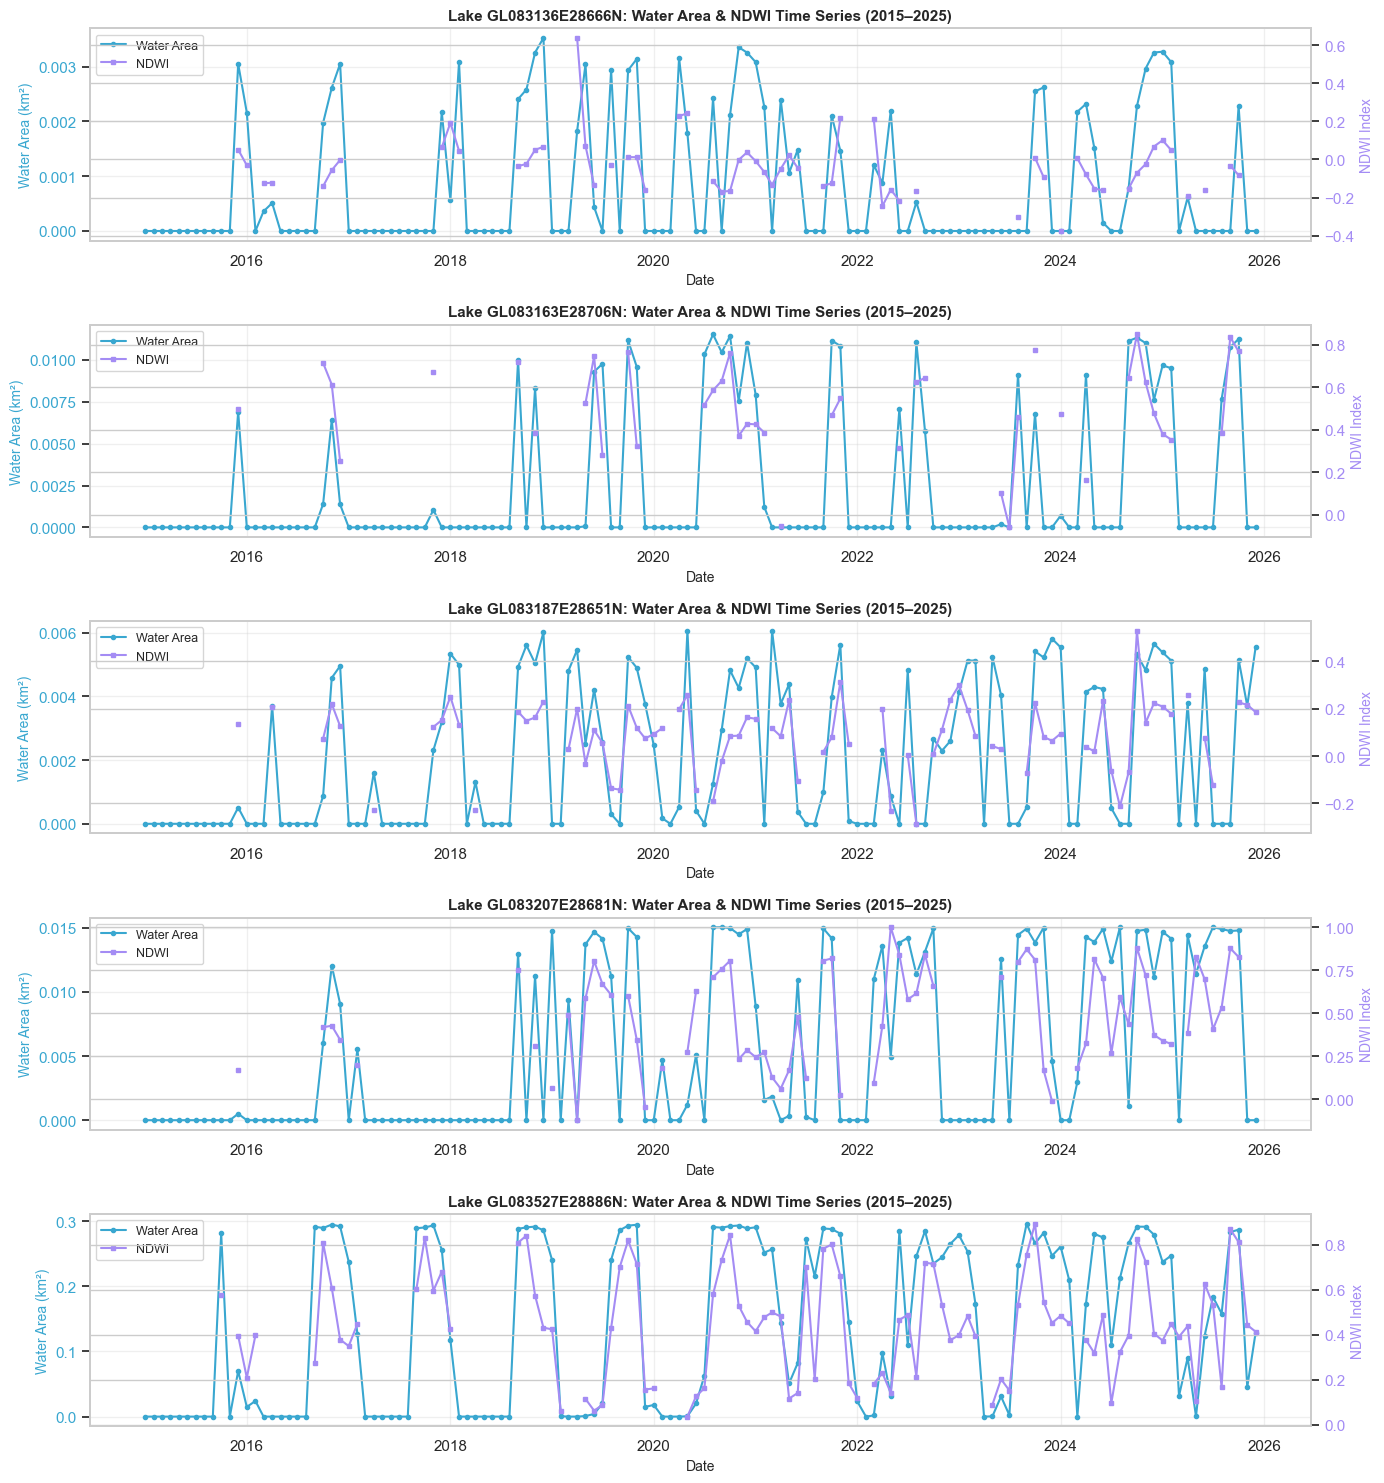

Saved: 09_sample_lakes_time_series.png


In [21]:
# Select 5 representative lakes for detailed time series analysis
sample_lakes = df['GL_ID'].unique()[:5]
print(f"\nSample lakes for detailed analysis: {sample_lakes}")

# Function to plot per-lake time series with dual y-axis
def plot_lake_water_ndwi(lake_id, ax_water, ax_ndwi):
    lake_data = df[df['GL_ID'] == lake_id].sort_values('date')
    
    # Water area on left y-axis
    ax_water.plot(lake_data['date'], lake_data['S2_water_area_km2'], 
                  marker='o', markersize=3, linewidth=1.5, color=color_palette[5], label='Water Area')
    ax_water.set_ylabel('Water Area (km²)', fontsize=10, color=color_palette[5])
    ax_water.tick_params(axis='y', labelcolor=color_palette[5])
    ax_water.grid(alpha=0.3)
    
    # NDWI on right y-axis
    ax_ndwi.plot(lake_data['date'], lake_data['S2_NDWI_mean'], 
                 marker='s', markersize=3, linewidth=1.5, color=color_palette[6], label='NDWI')
    ax_ndwi.set_ylabel('NDWI Index', fontsize=10, color=color_palette[6])
    ax_ndwi.tick_params(axis='y', labelcolor=color_palette[6])

# Create subplots for each sample lake
fig, axes = plt.subplots(len(sample_lakes), 1, figsize=(14, 3*len(sample_lakes)))

for idx, lake_id in enumerate(sample_lakes):
    ax1 = axes[idx]
    ax2 = ax1.twinx()
    
    lake_data = df[df['GL_ID'] == lake_id].sort_values('date')
    
    # Water area
    ax1.plot(lake_data['date'], lake_data['S2_water_area_km2'], 
             marker='o', markersize=3, linewidth=1.5, color=color_palette[5], label='Water Area', zorder=2)
    ax1.set_ylabel('Water Area (km²)', fontsize=10, color=color_palette[5])
    ax1.tick_params(axis='y', labelcolor=color_palette[5])
    ax1.set_xlabel('Date', fontsize=10)
    
    # NDWI
    ax2.plot(lake_data['date'], lake_data['S2_NDWI_mean'], 
             marker='s', markersize=3, linewidth=1.5, color=color_palette[6], label='NDWI', zorder=2)
    ax2.set_ylabel('NDWI Index', fontsize=10, color=color_palette[6])
    ax2.tick_params(axis='y', labelcolor=color_palette[6])
    
    ax1.set_title(f'Lake {lake_id}: Water Area & NDWI Time Series (2015–2025)', fontsize=11, fontweight='bold')
    ax1.grid(alpha=0.3)
    
    # Legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / '09_sample_lakes_time_series.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 09_sample_lakes_time_series.png")

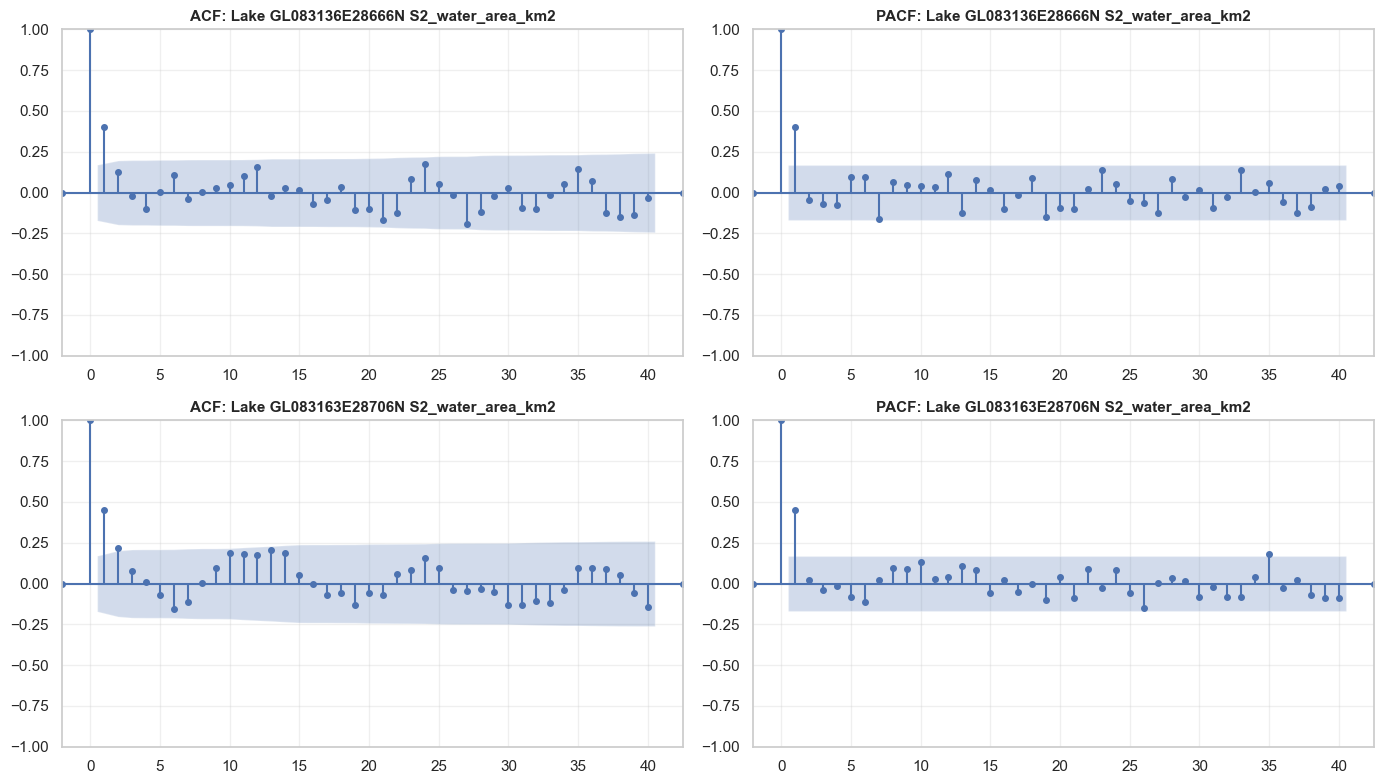

Saved: 10_acf_pacf_sample_lakes.png


In [22]:
# ACF and PACF plots for 2 sample lakes (with NaN interpolation)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, lake_id in enumerate(sample_lakes[:2]):
    lake_data = df[df['GL_ID'] == lake_id].sort_values('date')['S2_water_area_km2'].values
    
    # Linear interpolation for NaNs
    lake_series = pd.Series(lake_data)
    lake_series_filled = lake_series.interpolate(method='linear', limit_direction='both').bfill().ffill()
    
    # ACF
    plot_acf(lake_series_filled, lags=40, ax=axes[idx, 0], marker='o', markersize=4)
    axes[idx, 0].set_title(f'ACF: Lake {lake_id} S2_water_area_km2', fontsize=11, fontweight='bold')
    axes[idx, 0].grid(alpha=0.3)
    
    # PACF
    plot_pacf(lake_series_filled, lags=40, ax=axes[idx, 1], marker='o', markersize=4)
    axes[idx, 1].set_title(f'PACF: Lake {lake_id} S2_water_area_km2', fontsize=11, fontweight='bold')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '10_acf_pacf_sample_lakes.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 10_acf_pacf_sample_lakes.png")

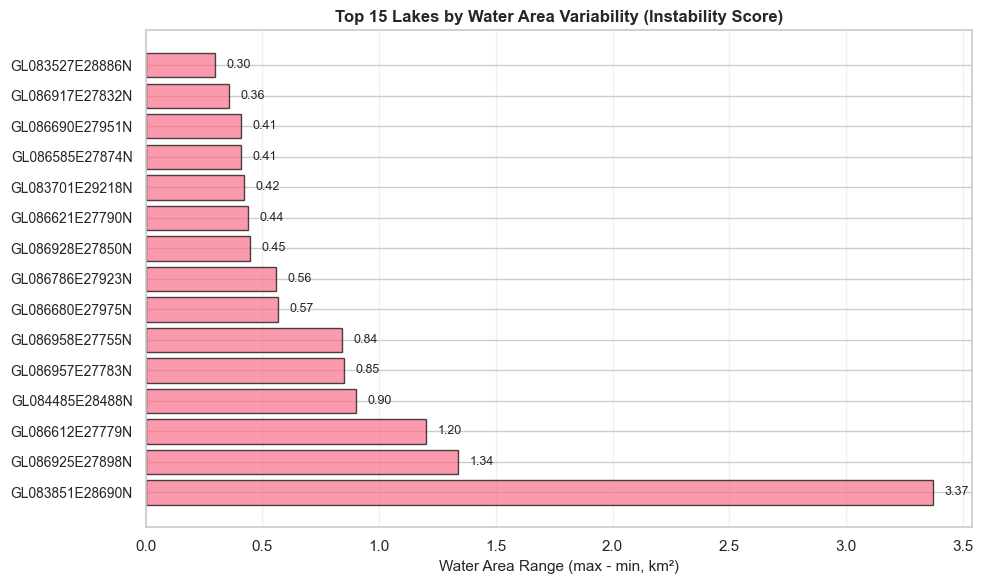

Saved: 11_lake_variability_ranking.png

Top 15 Most Variable Lakes:
                   std  range   mean  count
GL_ID                                      
GL083851E28690N  1.465  3.371  1.363    132
GL086925E27898N  0.562  1.336  0.545    132
GL086612E27779N  0.494  1.202  0.478    132
GL084485E28488N  0.398  0.901  0.516    132
GL086957E27783N  0.342  0.849  0.392    132
GL086958E27755N  0.362  0.841  0.368    132
GL086680E27975N  0.228  0.566  0.248    132
GL086786E27923N  0.228  0.556  0.171    132
GL086928E27850N  0.168  0.445  0.157    132
GL086621E27790N  0.174  0.439  0.163    132
GL083701E29218N  0.167  0.421  0.206    132
GL086585E27874N  0.174  0.408  0.187    132
GL086690E27951N  0.185  0.408  0.229    132
GL086917E27832N  0.121  0.356  0.108    132
GL083527E28886N  0.127  0.296  0.138    132


In [23]:
# Per-lake variability: std and range of S2_water_area_km2
lake_variability = df.groupby('GL_ID')['S2_water_area_km2'].agg([
    ('std', 'std'),
    ('range', lambda x: x.max() - x.min()),
    ('mean', 'mean'),
    ('count', 'count')
]).sort_values('range', ascending=False)

# Top 15 most variable lakes
top_variable = lake_variability.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top_variable)), top_variable['range'].values, color=color_palette[0], alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_variable)))
ax.set_yticklabels(top_variable.index, fontsize=10)
ax.set_xlabel('Water Area Range (max - min, km²)', fontsize=11)
ax.set_title('Top 15 Lakes by Water Area Variability (Instability Score)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, val in enumerate(top_variable['range'].values):
    ax.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / '11_lake_variability_ranking.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 11_lake_variability_ranking.png")
print("\nTop 15 Most Variable Lakes:")
print(top_variable.round(3).to_string())

---

## 4. Cross-Sensor Correlation

**Why this matters**: High correlations between sensors reveal redundancy and potential multicollinearity, while low correlations indicate complementary information. This is essential for feature selection and avoiding overfitting in downstream anomaly detection models.

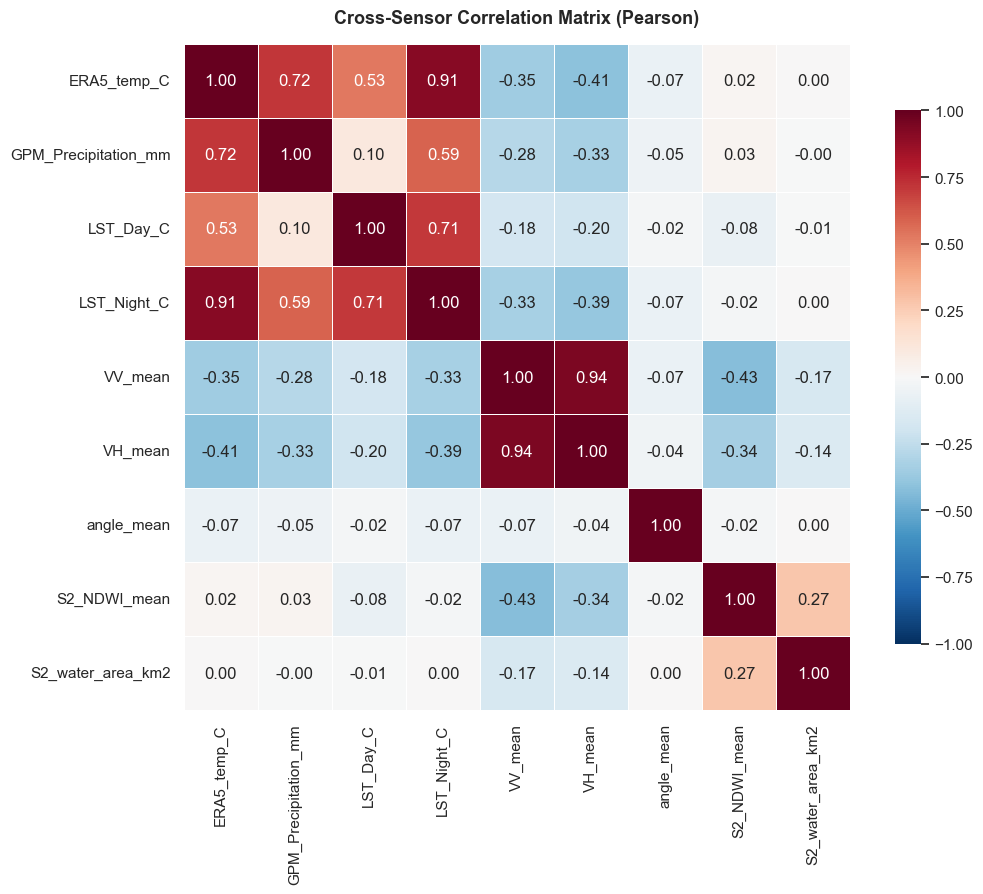

Saved: 12_cross_sensor_correlation.png


In [24]:
# Correlation heatmap for 9 core sensor variables
sensor_vars = ['ERA5_temp_C', 'GPM_Precipitation_mm', 'LST_Day_C', 'LST_Night_C', 
                'VV_mean', 'VH_mean', 'angle_mean', 'S2_NDWI_mean', 'S2_water_area_km2']

corr_matrix = df[sensor_vars].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Cross-Sensor Correlation Matrix (Pearson)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(output_dir / '12_cross_sensor_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 12_cross_sensor_correlation.png")

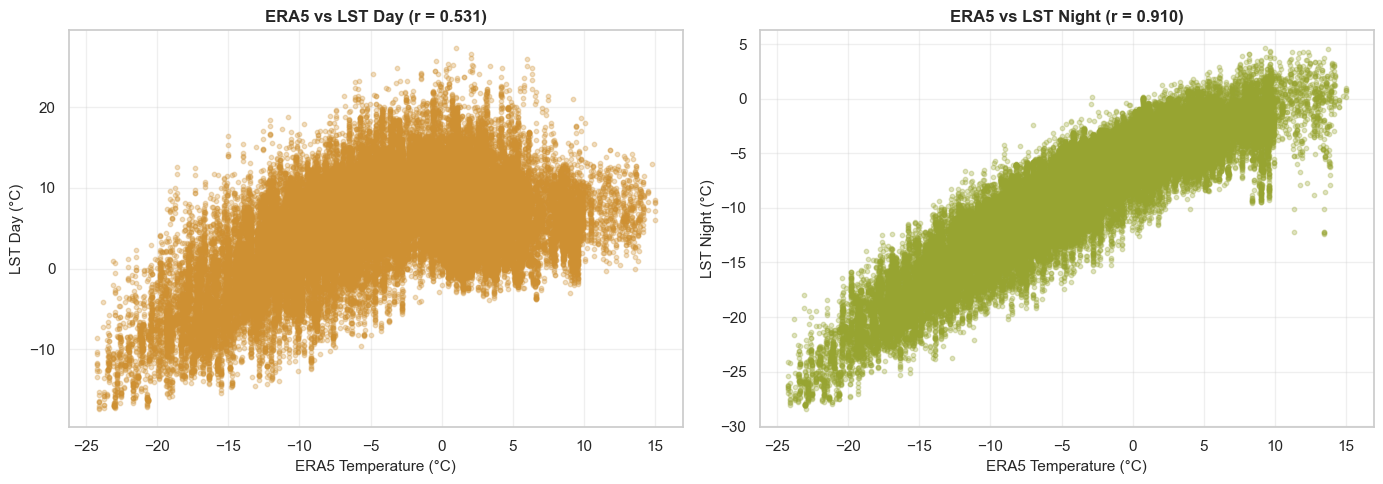

Saved: 13_temperature_scatter.png


In [25]:
# Scatter plots: Temperature variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ERA5_temp_C vs LST_Day_C
corr_era5_lst_day = df['ERA5_temp_C'].corr(df['LST_Day_C'])
axes[0].scatter(df['ERA5_temp_C'], df['LST_Day_C'], alpha=0.3, s=10, color=color_palette[1])
axes[0].set_xlabel('ERA5 Temperature (°C)', fontsize=11)
axes[0].set_ylabel('LST Day (°C)', fontsize=11)
axes[0].set_title(f'ERA5 vs LST Day (r = {corr_era5_lst_day:.3f})', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# ERA5_temp_C vs LST_Night_C
corr_era5_lst_night = df['ERA5_temp_C'].corr(df['LST_Night_C'])
axes[1].scatter(df['ERA5_temp_C'], df['LST_Night_C'], alpha=0.3, s=10, color=color_palette[2])
axes[1].set_xlabel('ERA5 Temperature (°C)', fontsize=11)
axes[1].set_ylabel('LST Night (°C)', fontsize=11)
axes[1].set_title(f'ERA5 vs LST Night (r = {corr_era5_lst_night:.3f})', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '13_temperature_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 13_temperature_scatter.png")

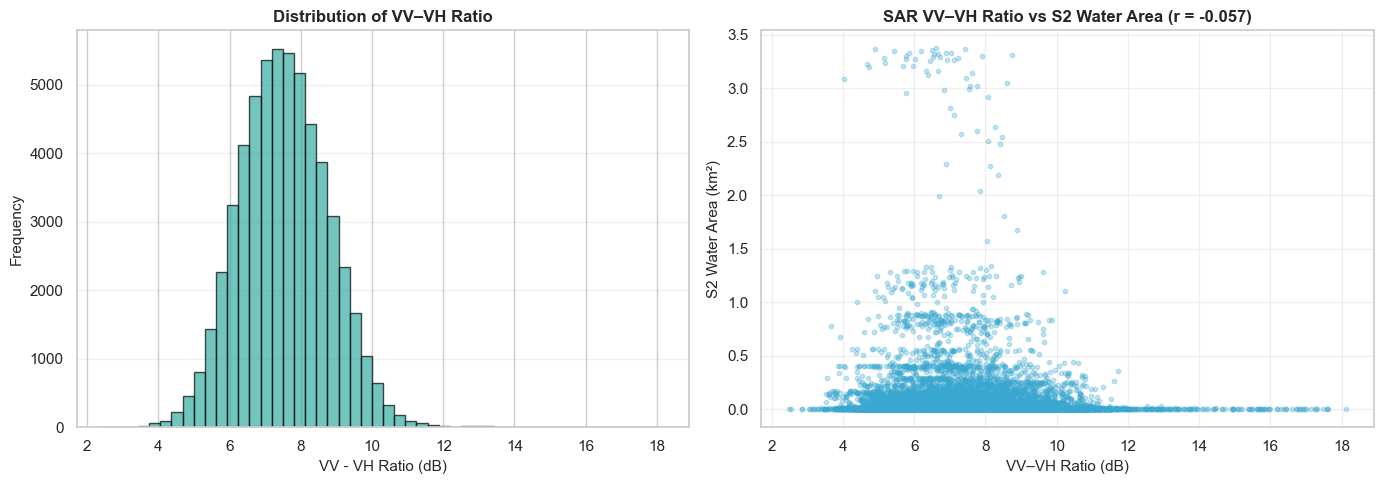

Saved: 14_vv_vh_ratio_analysis.png


In [26]:
# Derive VV_VH_ratio and correlate with water area
df['VV_VH_ratio'] = df['VV_mean'] - df['VH_mean']  # dB domain subtraction

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VV_VH_ratio distribution
axes[0].hist(df['VV_VH_ratio'].dropna(), bins=50, color=color_palette[4], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('VV - VH Ratio (dB)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of VV–VH Ratio', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# VV_VH_ratio vs S2_water_area_km2
corr_vv_vh_water = df['VV_VH_ratio'].corr(df['S2_water_area_km2'])
axes[1].scatter(df['VV_VH_ratio'], df['S2_water_area_km2'], alpha=0.3, s=10, color=color_palette[5])
axes[1].set_xlabel('VV–VH Ratio (dB)', fontsize=11)
axes[1].set_ylabel('S2 Water Area (km²)', fontsize=11)
axes[1].set_title(f'SAR VV–VH Ratio vs S2 Water Area (r = {corr_vv_vh_water:.3f})', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '14_vv_vh_ratio_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 14_vv_vh_ratio_analysis.png")

---

## 5. Scan Count / Data Density Sanity Check

**Why this matters**: Scan counts and observation counts track sensor availability and data density. Sudden dips in these metrics can indicate sensor maintenance, orbital adjustments, or data processing issues that need to be accounted for when interpreting anomalies.

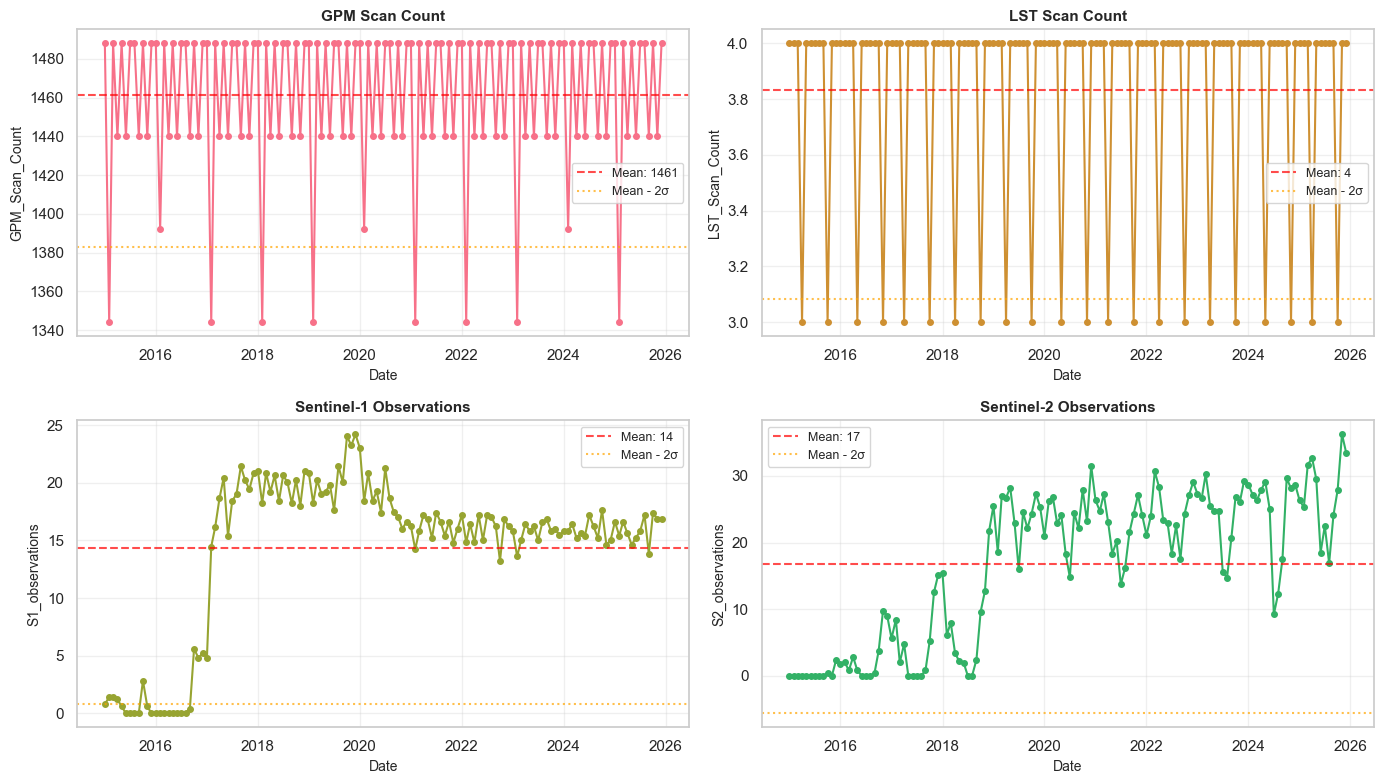

Saved: 15_scan_count_density.png


In [27]:
# Monthly average scan counts and observations
monthly_density = df.groupby('date').agg({
    'GPM_Scan_Count': 'mean',
    'LST_Scan_Count': 'mean',
    'S1_observations': 'mean',
    'S2_observations': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

density_vars = ['GPM_Scan_Count', 'LST_Scan_Count', 'S1_observations', 'S2_observations']
titles = ['GPM Scan Count', 'LST Scan Count', 'Sentinel-1 Observations', 'Sentinel-2 Observations']

for idx, (var, title) in enumerate(zip(density_vars, titles)):
    ax = axes[idx // 2, idx % 2]
    
    mean_val = monthly_density[var].mean()
    std_val = monthly_density[var].std()
    
    ax.plot(monthly_density['date'], monthly_density[var], 
            marker='o', markersize=4, linewidth=1.5, color=color_palette[idx % len(color_palette)])
    ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Mean: {mean_val:.0f}')
    ax.axhline(mean_val - 2*std_val, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Mean - 2σ')
    
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel(var, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '15_scan_count_density.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 15_scan_count_density.png")

In [28]:
# Flag months with anomalously low scan counts (>2 std below mean)
print("\n" + "="*70)
print("ANOMALOUS DATA DENSITY DETECTION")
print("="*70)

for var in density_vars:
    mean_val = monthly_density[var].mean()
    std_val = monthly_density[var].std()
    threshold = mean_val - 2 * std_val
    
    anomalous = monthly_density[monthly_density[var] < threshold]
    
    if len(anomalous) > 0:
        print(f"\n⚠ {var}: {len(anomalous)} months with count < {threshold:.0f}")
        print(anomalous[['date', var]].to_string(index=False))
    else:
        print(f"\n✓ {var}: No anomalous dips detected (threshold: {threshold:.0f})")


ANOMALOUS DATA DENSITY DETECTION

⚠ GPM_Scan_Count: 8 months with count < 1383
      date  GPM_Scan_Count
2015-02-01          1344.0
2017-02-01          1344.0
2018-02-01          1344.0
2019-02-01          1344.0
2021-02-01          1344.0
2022-02-01          1344.0
2023-02-01          1344.0
2025-02-01          1344.0

⚠ LST_Scan_Count: 22 months with count < 3
      date  LST_Scan_Count
2015-04-01             3.0
2015-10-01             3.0
2016-05-01             3.0
2016-11-01             3.0
2017-04-01             3.0
2017-10-01             3.0
2018-04-01             3.0
2018-10-01             3.0
2019-04-01             3.0
2019-10-01             3.0
2020-05-01             3.0
2020-11-01             3.0
2021-04-01             3.0
2021-10-01             3.0
2022-04-01             3.0
2022-10-01             3.0
2023-04-01             3.0
2023-10-01             3.0
2024-05-01             3.0
2024-11-01             3.0
2025-04-01             3.0
2025-10-01             3.0

⚠ S1_observ

---

## 6. Lake-Level Risk Proxies: Size, Growth & Extreme Events

**Why this matters**: Static lake size alone does not predict GLOF hazard — a small lake expanding rapidly can pose more immediate risk than a large, stable one. This section separates "biggest" from "fastest-changing," and flags candidate rapid-expansion events using a naive threshold approach. Both serve as sanity-check baselines against which the Stage 1 LSTM-Autoencoder's learned, multi-feature anomaly scores can later be compared.

### 6.1 Top 10 Lakes by Static Inventory Area (ICIMOD)

In [29]:
from pathlib import Path

import pandas as pd


project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

inventory_file = project_root / "data" / "inventory" / "final_glaciers_master.csv"

lake_inventory = pd.read_csv(inventory_file)
lake_inventory["Area"] = pd.to_numeric(lake_inventory["Area"], errors="raise")

top_10_lakes = (
    lake_inventory
    .sort_values(["Area", "GL_ID"], ascending=[False, True])
    .head(10)
    [["Id", "GL_ID", "Area", "Basin", "Sub_Basin", "Elevation"]]
    .reset_index(drop=True)
)

top_10_lakes.index = top_10_lakes.index + 1
top_10_lakes.index.name = "Rank"
top_10_lakes.round({"Area": 6})

,Id,GL_ID,Area,Basin,Sub_Basin,Elevation
Rank,,,,,,
1,291,GL083851E28690N,3.384128,Gandaki,Marsyangdi,4910
2,92,GL086925E27898N,1.342831,Koshi,Dudh Koshi,5002
3,91,GL086612E27779N,1.218551,Koshi,Dudh Koshi,4829
4,194,GL084485E28488N,0.925657,Gandaki,Marsyangdi,4033
5,957,GL086957E27783N,0.868498,Koshi,Dudh Koshi,5197
6,956,GL086958E27755N,0.863273,Koshi,Dudh Koshi,4936
7,285,GL086680E27975N,0.571353,Koshi,Dudh Koshi,4834
8,529,GL086786E27923N,0.562661,Koshi,Dudh Koshi,4502
9,90,GL086621E27790N,0.457740,Koshi,Dudh Koshi,5146


### 6.2 Biggest vs. Fastest-Growing Lakes (Size ≠ Risk)


BIGGEST LAKES vs. FASTEST-GROWING LAKES

Lakes with valid trend fit (n >= 12 months): 494 / 494
Lakes excluded from growth/shrink ranking (mean area <= 0.01 km²): 391
Lakes eligible for growth/shrink ranking: 103
Lakes appearing in BOTH top-10-by-size and top-10-by-growth-rate: 9 / 10
['GL083851E28690N', 'GL084485E28488N', 'GL086585E27874N', 'GL086612E27779N', 'GL086680E27975N', 'GL086690E27951N', 'GL086925E27898N', 'GL086957E27783N', 'GL086958E27755N']


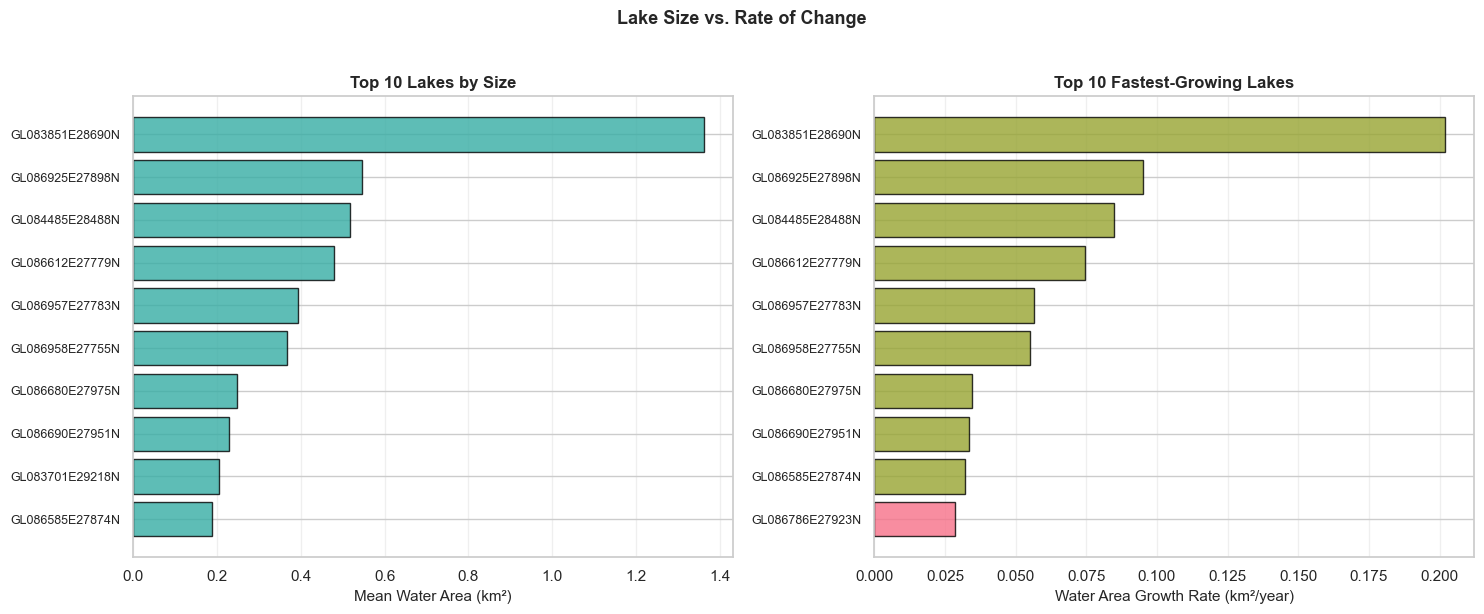

Saved: 16_size_vs_growth_comparison.png

Top 10 Fastest-Growing Lakes (linear trend, km²/year, mean area > 0.01 km²):
                 mean_area_km2  slope_km2_per_year  pct_change_per_year  n_obs
GL_ID                                                                         
GL083851E28690N         1.3633              0.2021              14.8211    132
GL086925E27898N         0.5452              0.0950              17.4158    132
GL084485E28488N         0.5163              0.0849              16.4448    132
GL086612E27779N         0.4783              0.0747              15.6066    132
GL086957E27783N         0.3923              0.0564              14.3733    132
GL086958E27755N         0.3677              0.0551              14.9842    132
GL086680E27975N         0.2484              0.0347              13.9534    132
GL086690E27951N         0.2288              0.0334              14.5977    132
GL086585E27874N         0.1871              0.0320              17.0850    132
GL086786E2792

In [32]:
# Linear trend (slope) of S2_water_area_km2 per lake, in km²/year
# Using the actual multi-sensor time series (not the static ICIMOD inventory area)
df['years_since_start'] = (df['date'] - df['date'].min()).dt.days / 365.25

MIN_OBS = 12       # require at least ~1 year of valid water-area readings to fit a trend
MIN_AREA_KM2 = 0.01  # exclude near-empty/noise lakes (<1 hectare mean area) from growth/shrink ranking

trend_records = []
for gl_id, g in df.groupby('GL_ID'):
    g = g.dropna(subset=['S2_water_area_km2'])
    if len(g) < MIN_OBS:
        continue
    x = g['years_since_start'].values
    y = g['S2_water_area_km2'].values
    slope, intercept = np.polyfit(x, y, 1)
    mean_area = y.mean()
    pct_change_per_year = (slope / mean_area * 100) if mean_area > 0 else np.nan
    trend_records.append({
        'GL_ID': gl_id,
        'mean_area_km2': mean_area,
        'slope_km2_per_year': slope,
        'pct_change_per_year': pct_change_per_year,
        'n_obs': len(g)
    })

lake_trends = pd.DataFrame(trend_records).set_index('GL_ID')

# Filter out near-empty lakes before ranking growth/shrink — below this size,
# NDWI-based water detection is noisy and slope/pct_change become numerical artifacts
# rather than real signal (a few m² of measurement noise can look like "17% growth").
n_excluded = (lake_trends['mean_area_km2'] <= MIN_AREA_KM2).sum()
lake_trends_ranked = lake_trends[lake_trends['mean_area_km2'] > MIN_AREA_KM2]

top10_by_size = lake_trends.sort_values('mean_area_km2', ascending=False).head(10)
top10_by_growth = lake_trends_ranked.sort_values('slope_km2_per_year', ascending=False).head(10)
top10_by_shrink = lake_trends_ranked.sort_values('slope_km2_per_year', ascending=True).head(10)

overlap = set(top10_by_size.index) & set(top10_by_growth.index)

print("\n" + "="*70)
print("BIGGEST LAKES vs. FASTEST-GROWING LAKES")
print("="*70)
print(f"\nLakes with valid trend fit (n >= {MIN_OBS} months): {len(lake_trends)} / {df['GL_ID'].nunique()}")
print(f"Lakes excluded from growth/shrink ranking (mean area <= {MIN_AREA_KM2} km²): {n_excluded}")
print(f"Lakes eligible for growth/shrink ranking: {len(lake_trends_ranked)}")
print(f"Lakes appearing in BOTH top-10-by-size and top-10-by-growth-rate: {len(overlap)} / 10")
if overlap:
    print(sorted(overlap))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(range(len(top10_by_size)), top10_by_size['mean_area_km2'].values,
             color=color_palette[4], alpha=0.8, edgecolor='black')
axes[0].set_yticks(range(len(top10_by_size)))
axes[0].set_yticklabels(top10_by_size.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean Water Area (km²)', fontsize=11)
axes[0].set_title('Top 10 Lakes by Size', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

colors_growth = [color_palette[2] if gl in overlap else color_palette[0] for gl in top10_by_growth.index]
axes[1].barh(range(len(top10_by_growth)), top10_by_growth['slope_km2_per_year'].values,
             color=colors_growth, alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(len(top10_by_growth)))
axes[1].set_yticklabels(top10_by_growth.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Water Area Growth Rate (km²/year)', fontsize=11)
axes[1].set_title('Top 10 Fastest-Growing Lakes', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Lake Size vs. Rate of Change', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(output_dir / '16_size_vs_growth_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 16_size_vs_growth_comparison.png")

print("\nTop 10 Fastest-Growing Lakes (linear trend, km²/year, mean area > "
      f"{MIN_AREA_KM2} km²):")
print(top10_by_growth[['mean_area_km2', 'slope_km2_per_year', 'pct_change_per_year', 'n_obs']].round(4).to_string())

print("\nTop 10 Fastest-Shrinking Lakes (linear trend, km²/year, mean area > "
      f"{MIN_AREA_KM2} km²):")
print(top10_by_shrink[['mean_area_km2', 'slope_km2_per_year', 'pct_change_per_year', 'n_obs']].round(4).to_string())

### 6.3 Extreme Month-over-Month Water Area Jumps


TOP 15 EXTREME MONTH-OVER-MONTH WATER AREA JUMPS
(|change| > 2 std of that lake's own month-over-month variability)

          GL_ID       date  S2_water_area_km2  area_diff  jump_zscore
GL083851E28690N 2024-10-01             3.3575     3.3575       2.4768
GL083851E28690N 2020-08-01             3.2804     3.2804       2.4199
GL083851E28690N 2024-07-01             0.0000    -3.2602      -2.4050
GL083851E28690N 2016-10-01             3.2568     3.2568       2.4025
GL083851E28690N 2017-11-01             3.2301     3.2301       2.3828
GL083851E28690N 2022-01-01             0.0527    -3.2105      -2.3683
GL083851E28690N 2018-11-01             3.2073     3.2073       2.3660
GL083851E28690N 2018-12-01             0.0810    -3.1263      -2.3062
GL083851E28690N 2020-01-01             0.0161    -3.1063      -2.2915
GL083851E28690N 2018-09-01             3.0981     3.0981       2.2854
GL083851E28690N 2018-10-01             0.0000    -3.0981      -2.2854
GL083851E28690N 2017-01-01             0.0

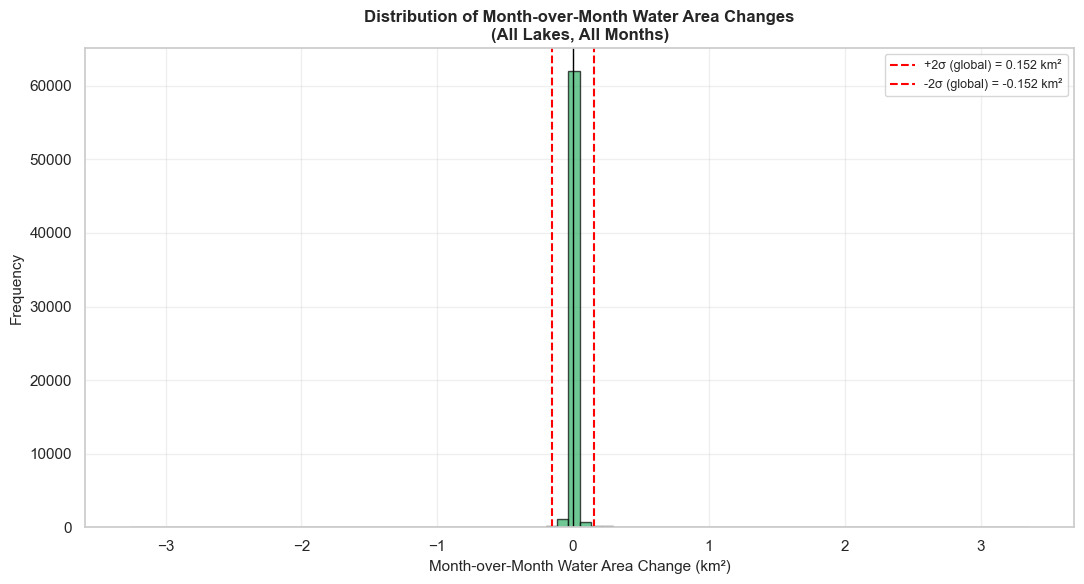


Saved: 17_extreme_jumps_histogram.png

Total flagged extreme events (lake-specific >2σ): 6299
Unique lakes with at least one flagged event: 491


In [31]:
# Naive anomaly-flagging baseline: month-over-month change in S2_water_area_km2,
# flagged per-lake at > 2 standard deviations of that lake's own change distribution.
# This previews (on one variable, with a fixed threshold) what the Stage 1
# LSTM-Autoencoder will later do jointly across all 7 temporal features, learning
# the normal pattern per lake instead of relying on a fixed statistical cutoff.

df_sorted = df.sort_values(['GL_ID', 'date']).copy()
df_sorted['area_diff'] = df_sorted.groupby('GL_ID')['S2_water_area_km2'].diff()

lake_diff_std = df_sorted.groupby('GL_ID')['area_diff'].transform('std')
df_sorted['jump_zscore'] = df_sorted['area_diff'] / lake_diff_std

valid_diffs = df_sorted.dropna(subset=['area_diff', 'jump_zscore'])
extreme_jumps = (
    valid_diffs.loc[valid_diffs['jump_zscore'].abs() > 2]
    .assign(abs_diff=lambda d: d['area_diff'].abs())
    .sort_values('abs_diff', ascending=False)
    .head(15)
    [['GL_ID', 'date', 'S2_water_area_km2', 'area_diff', 'jump_zscore']]
)

print("\n" + "="*70)
print("TOP 15 EXTREME MONTH-OVER-MONTH WATER AREA JUMPS")
print("="*70)
print("(|change| > 2 std of that lake's own month-over-month variability)\n")
print(extreme_jumps.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
all_diffs = df_sorted['area_diff'].dropna()
ax.hist(all_diffs, bins=80, color=color_palette[3], alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
global_std = all_diffs.std()
ax.axvline(2*global_std, color='red', linestyle='--', linewidth=1.5,
           label=f'+2σ (global) = {2*global_std:.3f} km²')
ax.axvline(-2*global_std, color='red', linestyle='--', linewidth=1.5,
           label=f'-2σ (global) = {-2*global_std:.3f} km²')
ax.set_xlabel('Month-over-Month Water Area Change (km²)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Month-over-Month Water Area Changes\n(All Lakes, All Months)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / '17_extreme_jumps_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: 17_extreme_jumps_histogram.png")

n_flagged = (df_sorted['jump_zscore'].abs() > 2).sum()
print(f"\nTotal flagged extreme events (lake-specific >2σ): {n_flagged}")
print(f"Unique lakes with at least one flagged event: {df_sorted.loc[df_sorted['jump_zscore'].abs() > 2, 'GL_ID'].nunique()}")


**Note**: Both 6.2 and 6.3 are simple, explainable baselines built directly into the EDA — they are not the final model. They exist to (a) demonstrate that size and rate-of-change diverge, motivating a learned risk-ranking approach over static inventory sorting, and (b) give a naive single-variable reference point against which the multi-feature LSTM-Autoencoder anomaly scores (Stage 1) can later be sanity-checked.

## 7. Summary & Key Findings

### Missingness Mechanism & Seasonality

**Findings to complete after review:**

- **S2_NDWI_mean (~47% missing):**  
  - [ ] Document peak missingness month (monsoon?)  
  - [ ] Correlation between cloud cover and S2_observations = 0  
  - [ ] Implications for imputation strategy (e.g., forward-fill during monsoon windows)  

- **Sentinel-1 SAR (~12.6% missing):**  
  - [ ] Revisit cycle gaps or orbital discontinuities?  
  - [ ] Temporal or spatial patterns?  
  - [ ] Can SAR gaps be predictable (e.g., fixed orbital pattern)?  

### Data Quality Issues

- [ ] Any physically implausible values detected? (NDWI outside [−1, 1], negative precipitation, etc.)  
- [ ] Outliers in SAR backscatter or water area measurements?  
- [ ] Consistency check result: S2_observations = 0 ↔ S2_NDWI_mean null — % match?  

### Seasonal & Temporal Patterns

- [ ] Strong monsoon cycle in GPM precipitation (June–September peak)?  
- [ ] Temperature cycles (ERA5 vs LST) — are they aligned?  
- [ ] Water area temporal patterns — do they correlate with temperature/precipitation?  
- [ ] Most unstable (variable) lakes — geographic clusters or random?  

### Cross-Sensor Relationships

- [ ] High correlations between ERA5_temp_C and LST (day/night)?  
  - Implication: Potential redundancy; consider dropping one in autoencoder  
- [ ] SAR backscatter (VV/VH) — correlation with water area?  
  - Implication: SAR provides independent signal for water dynamics  
- [ ] VV–VH ratio — meaningful proxy for surface roughness/water properties?  

### Preprocessing Strategy for Autoencoder

- [ ] **Imputation approach for S2_NDWI (47% missing):**  
  - Forward-fill during monsoon gaps (known missing window)?  
  - Interpolate from seasonal climatology?  
  - Leave as missing (mask in autoencoder)?  

- [ ] **Imputation for SAR (~12.6% missing):**  
  - Interpolation across time?  
  - Spatial nearest-neighbor from nearby lakes?  

- [ ] **Feature scaling:**  
  - Normalize/standardize all continuous variables before autoencoder?  
  - Handle outliers (winsorization or removal)?  

- [ ] **Feature selection:**  
  - Drop ERA5_temp_C if LST_Day_C is highly correlated?  
  - Keep derived VV–VH_ratio as new feature?  

### Lake-Level Risk Proxies

- [ ] Do the top-10-by-size and top-10-by-growth-rate lake lists diverge? By how much?  
- [ ] Which districts/basins do the fastest-growing lakes cluster in?  
- [ ] How many extreme month-over-month jump events were flagged, and do they cluster in particular years or seasons (e.g., post-monsoon)?  
- [ ] Do any flagged extreme-jump lakes overlap with the Adhikari et al. (2025) focus lakes?  

### Next Steps

1. Document final conclusions for each section above.  
2. Finalize imputation and normalization pipeline in a dedicated preprocessing module.  
3. Prepare cleaned, normalized dataset for LSTM Autoencoder training.  
4. Reserve holdout lakes for validation of learned anomalies.